In [131]:
import jax.numpy as jnp
import jax
from jaxtyping import PRNGKeyArray

from jax import Array
from jax.typing import ArrayLike
from typing import Optional

from jaxopt import ProjectedGradient
from jaxopt.projection import projection_simplex
import optax

import jax_dataloader as jdl
from typing import Any, Callable, final
from typing_extensions import override

import matplotlib.pyplot as plt
import os

#os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]= 'platform'
#os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]= 'false'
#os.environ["TF_GPU_ALLOCATOR"]= 'cuda_malloc_async'
#os.environ.pop("PYTHONHOME")


In [132]:
#cmap = plt.cm("magma")
def make_colors(num_plots):
    colors = plt.cm.inferno(jnp.linspace(0,0.75,num_plots))
    return colors

In [133]:
fig_dir = "/mnt/home/levans/ensemble_reweighting/cryo_reweighting_examples/figures/comparing_optimizations"

In [134]:
data_directory = "/mnt/home/levans/ensemble_reweighting/cryo_reweighting_examples/data/likelihoods"
log_likelihood = jnp.load(f"{data_directory}/igg/log_likelihood_cryojax.npy")

# Define diagnostics shared across methods

In [135]:
@jax.jit
def grad_log_prob(weights: ArrayLike, likelihood: ArrayLike) -> Array:
    model = jnp.sum(likelihood*weights, axis=1)
    grad = jnp.mean(likelihood/model[:, jnp.newaxis], axis=0) 
    return grad

@jax.jit
def compute_loss(weights: ArrayLike, likelihood: ArrayLike) -> Array:
    loss = -jnp.mean(jnp.log(jnp.sum(likelihood*weights, axis=1)))
    return loss

@jax.jit
def update_stats(weights: ArrayLike, likelihood: ArrayLike, true_weights):
    loss = compute_loss(weights, likelihood)
    weights_error = jnp.sum(true_weights*jnp.log(true_weights/weights))
    #weights_error = jnp.sum(weights*jnp.log(weights/true_weights))
    #weights_error = 0.5*(jnp.sum(true_weights**2/weights) -  1)
    #weights_error = jnp.arccos(jnp.sum(true_weights**(0.5) * weights**(0.5)))
    #weights_error = jnp.sum((true_weights**(0.5) - weights**(0.5))**2)


    return loss, weights_error


In [136]:
@jax.jit
def update_weights(weights: ArrayLike, grad: ArrayLike) -> Array:
    weights = weights*grad

    return weights

@jax.jit
def update_weights_tikh(weights: ArrayLike, grad: ArrayLike, reg) -> Array:
    weights = weights*(grad - 200*reg*weights)
    weights /= jnp.sum(weights)
    return weights

@jax.jit
def update_weights_forward_kl(weights: ArrayLike, grad: ArrayLike, reg) -> Array:
    weights = weights*(grad - reg*(jnp.log(weights) +1))
    weights /= jnp.sum(weights)
    return weights

@jax.jit
def smooth_weights_reverse_kl(weights: ArrayLike, reg: float) -> Array:
    weights = (1.0 - reg)*weights + reg*jnp.ones_like(weights)/weights.shape[0]
    return weights

@jax.jit
def smooth_weights_forward_kl(weights: ArrayLike, reg: float) -> Array:
    weights = weights**(1.0 - reg)
    #weights = weights - reg*weights*(jnp.log(weights) - 1)
    weights /= jnp.sum(weights)

    return weights

def multiplicative_gradient(
    log_likelihood: ArrayLike,
    true_weights,
    tol: Optional[float] = 1e-8,
    max_iterations: Optional[float] = 100000,
    verbose: Optional[bool]=False,
    iter_freq: Optional[int] = 100,
    weights_init=None,
    reg=0.0,
    METHOD=None
):

    num_images, num_structures = log_likelihood.shape

    # Initialize Weights
    if weights_init == None:
        weights = (1/num_structures)*jnp.ones(num_structures)

    else:
        weights = weights_init
    # Subtracting the largest entry from each row of likelihood
    # The gradient is invariant to row scaling of likelihood, so this is valid
    # With this, we avoid working in log space for the grad and loss
    log_likelihood = log_likelihood - jnp.max(log_likelihood, 1)[:, jnp.newaxis]
    
    # NOTE: we cannot exponentiate this if previous step hasn't happened 
    likelihood = jnp.exp(log_likelihood)

    #U, S, Vh = jnp.linalg.svd(likelihood, full_matrices=False)
    #print(U.shape, S.shape, Vh.shape)
    #likelihood = jnp.dot(U[:,:10] * S[:10], Vh[:10, :]) 
    
    # Iterate
    stats = {}
    stats["loss"] = []
    stats["gap"] = []
    stats["gap_path"] = []
    stats["gap_path_kl"] = []

    stats["weights"] = []
    stats["weights_idx"] = []
    stats["weights_error"] = []
    for k in range(max_iterations):

        # Update weights
        grad = grad_log_prob(weights, likelihood)
        gap_path_kl = -1*jnp.sum(weights*jnp.log(weights)*grad) + jnp.sum(weights*jnp.log(weights))
        #gap_path_kl = jnp.mean(jnp.matmul(likelihood, weights)/jnp.matmul(likelihood,jnp.ones_like(weights)/weights.shape[0]))
        #gap_path_kl = jnp.mean(jnp.matmul(likelihood,jnp.ones_like(weights)/weights.shape[0])/jnp.matmul(likelihood, weights))

        if METHOD == "tikh":
            weights = update_weights_tikh(weights, grad, reg)
        elif METHOD == "forward_reg":
            weights = update_weights_forward_kl(weights, grad, reg)

        else:
            weights = update_weights(weights, grad)
            if METHOD == "forward_kl": 
                weights = smooth_weights_forward_kl(weights, reg)
            elif METHOD == "reverse_kl":
                weights = smooth_weights_reverse_kl(weights, reg)
        
        # update per iteration stats
        loss, weights_error  = update_stats(weights, likelihood, true_weights)
        # Check stopping criterion: this `gap` is an upper bound on our loss compared to optimal weights
        gap = jnp.max(grad) - 1
        gap_path = jnp.mean(grad) - 1
        
        if k % iter_freq == 0: 
            if verbose:
                print(f"Number of iterations:{k}")
                print(f"Gap: {gap}") 
            stats["weights"].append(weights)
            stats["weights_idx"].append(k)
        if gap < tol:
            print(f"Number of iterations: {k}")
            print("exiting!")
            break

        stats["loss"].append(loss)
        stats["gap"].append(gap)
        stats["gap_path"].append(gap_path)
        stats["gap_path_kl"].append(gap_path_kl)
 
        stats["weights_error"].append(weights_error)


    stats["weights"] = jnp.stack(stats["weights"])
    stats["loss"] = jnp.stack(stats["loss"])
    stats["weights_idx"] = jnp.stack(stats["weights_idx"])
    stats["weights_error"] = jnp.stack(stats["weights_error"])
    return weights, stats

In [137]:
log_likelihood = log_likelihood - jnp.max(log_likelihood, 1)[:, jnp.newaxis]
# NOTE: we cannot exponentiate this if previous step hasn't happened 
likelihood = jnp.exp(log_likelihood)


# Define ground truth

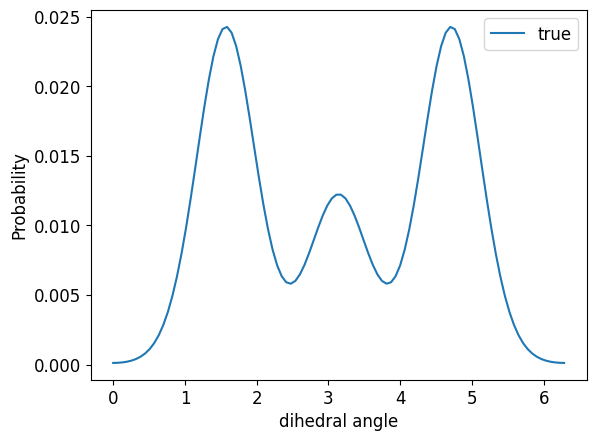

In [138]:
from scipy.stats import vonmises

## Define density that volumes are resampled from
def p(x):
    means = [jnp.pi/2, jnp.pi, 3*jnp.pi/2]
    kappas =  [6.0, 6.0, 6.0]
    weights = jnp.array([2.0, 1.0, 2.0])
    weights /= sum(weights)  
    val = 0
    for i in range(3): 
        val += weights[i]*vonmises.pdf(x, loc=means[i], kappa=kappas[i])
    return val

x = jnp.linspace(0, 2*jnp.pi, 100)
true_weights = p(x)
true_weights /= (jnp.sum(true_weights))

dx = x[1] - x[0]

# normalize output to integrate to 1 on the grid 
true_weights /= true_weights.sum() 
plt.plot(x, true_weights, label='true', color="C0")
#plt.xticks(jnp.arange(0, 20, 2))
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.legend()
plt.savefig(f"{fig_dir}/true_prob.png", dpi=300)
plt.show()

In [139]:
regs = jnp.linspace(0, 0.01, 10)

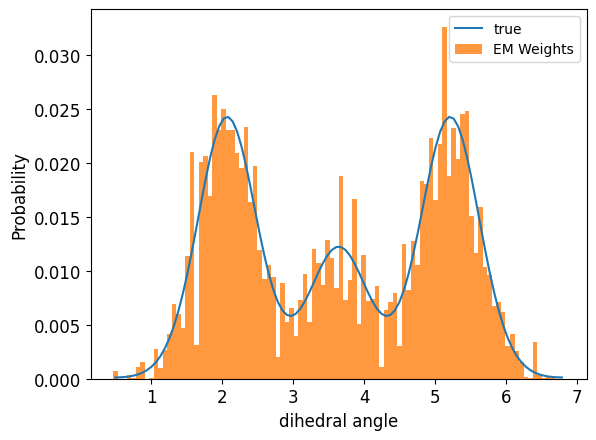

In [147]:
nodes = jnp.linspace(0, 2*jnp.pi, 100) + 0.5


ensemble_weights, stats = multiplicative_gradient(log_likelihood, true_weights, max_iterations=1000, iter_freq=1, tol=-1)
plt.plot(nodes, true_weights, label='true', color="C0")
plt.bar(nodes, ensemble_weights, width=dx, label='EM Weights', color="C1", alpha=0.8)
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.legend(fontsize=10)

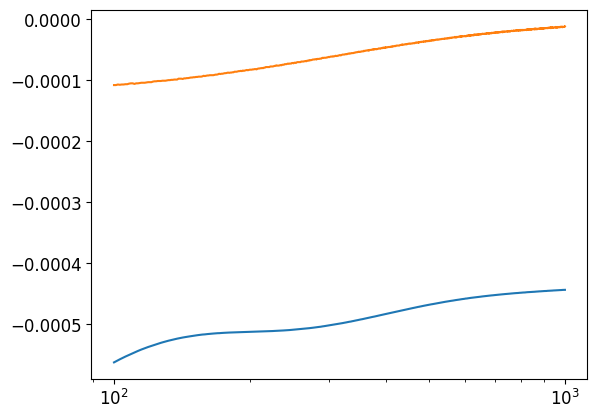

In [149]:
import numpy as np

losses = stats["loss"]
check_idx = 100
idx = np.arange(check_idx, len(losses), 1)
plt.figure()
plt.rcParams.update({'font.size': 12})
gap = stats["gap"]
gap_path_kl = stats["gap_path_kl"]
gap_path = stats["gap_path"]
#plt.semilogx(idx, gap[check_idx:])
plt.semilogx(idx, gap_path[check_idx:])
plt.semilogx(idx, gap_path_kl[check_idx:])

    

NameError: name 'colors' is not defined

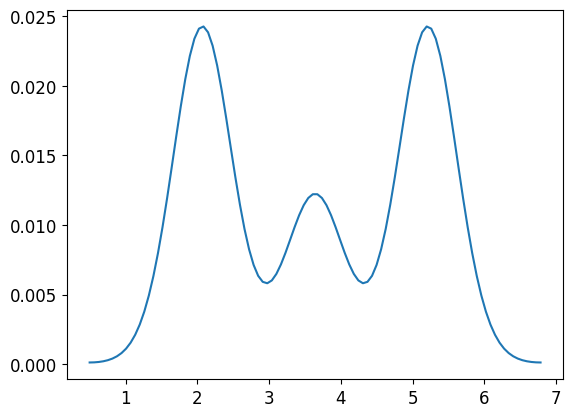

In [142]:
plt.figure()
plt.rcParams.update({'font.size': 12})
plt.plot(nodes, true_weights, label='true', color="C0")

weights_init = jnp.ones(nodes.shape[0])
weights_init /= jnp.sum(weights_init)
soft_weights, _ = multiplicative_gradient(log_likelihood, true_weights, max_iterations=1, iter_freq=1,tol=np.log(1.01))
ensemble_weights, stats = multiplicative_gradient(log_likelihood, true_weights, max_iterations=100, iter_freq=1,tol=np.log(1.001))
regs = jnp.linspace(0, 0.9, 10)
for i in range(len(regs)):
    reg = regs[i]
    #weights_reg = (1-reg)*ensemble_weights + reg*weights_init
    weights_reg = ensemble_weights**(1-reg)
    weights_reg /= jnp.sum(weights_reg)
    plt.step(nodes, weights_reg, 
             label='EM Weights', color=colors[i])
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.savefig(f"{fig_dir}/weight_comparison_forward.png", dpi=300)

plt.figure()
plt.rcParams.update({'font.size': 12})
plt.plot(nodes, true_weights, label='true', color="C0")
for i in range(len(regs)):
    reg = regs[i]
    weights_reg = (1-reg)*ensemble_weights + reg*weights_init
    #weights_reg = ensemble_weights**(1-reg)
    weights_reg /= jnp.sum(weights_reg)
    plt.step(nodes, weights_reg, 
             label='EM Weights', color=colors[i])
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.savefig(f"{fig_dir}/weight_comparison_reverse.png", dpi=300)



